Решить задачу классификации при помощи обучения модели логистической регрессии. Целевая переменная — пол спортсмена. Качество модели оценивается путем подсчета метрик TPR, FPR и построения графиков ROC-кривой, Precision-Recall. Данные для обучения модели хранятся в файле athletes.csv, который можно найти в материалах к занятию.

- Преобразуйте данные:

a. проверьте наличие пропущенных значений. Преобразуйте/удалите пропуски по необходимости;

b. закодируйте категориальные переменные числовыми значениями по необходимости.
- Разделите выборку на обучающее (80% данных) и тестовое (20% данных) подмножества.
- Постройте ROC-кривую с помощью функции roc_curve из библиотеки sklearn.metrics.
- Вычислите значение ROC-AUC метрики с помощью функции roc_auc_score из библиотеки sklearn.metrics.
- Реализуйте подсчет метрик TPR, FPR «вручную», без использования готовых функций из библиотеки sklearn.
- Постройте ROC-кривую с помощью вычисленных в п. 5 метрик. Объедините графики из п. 3 и п. 6 в один. Сравните, сделайте вывод.
- Постройте график Precision-Recall, используя метрики, посчитанные в п. 5.
- *Вычислите значение ROC-AUC метрики, используя метрики, посчитанные в п. 5.
- Сформулируйте выводы по проделанной работе:

a) как по полученным графикам сделать вывод о качестве модели? Как вы оцениваете обученную модель исходя из подсчитанных метрик?

b) *может ли ROC-кривая проходить ниже диагонали?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

☝ 1 вариант

In [ ]:
data = pd.read_csv('athletes.csv')
data.head(3)

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [ ]:
data.isnull().sum()

,0
id,0
name,0
nationality,0
sex,0
dob,1
height,330
weight,659
sport,0
gold,0
silver,0


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.isna().sum()

,0
id,0
name,0
nationality,0
sex,0
dob,0
height,0
weight,0
sport,0
gold,0
silver,0


In [ ]:
label = LabelEncoder()
target = label.fit_transform(data['sex'])

In [ ]:
x = pd.get_dummies(data[['height',	'weight', 'sport']])

In [ ]:
x.head(3)

,height,weight,sport_aquatics,sport_archery,sport_athletics,sport_badminton,sport_basketball,sport_canoe,sport_cycling,sport_equestrian,...,sport_rugby sevens,sport_sailing,sport_shooting,sport_table tennis,sport_taekwondo,sport_tennis,sport_triathlon,sport_volleyball,sport_weightlifting,sport_wrestling
0,1.72,64.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.68,56.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.98,79.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, target, test_size=0.2, random_state=0)

In [ ]:
model = LogisticRegression(max_iter=5000).fit(x_train, y_train)
pred = model.predict_proba(x_test)

In [ ]:
fpr, tpr, _ = roc_curve(y_test, pred[:, 1])

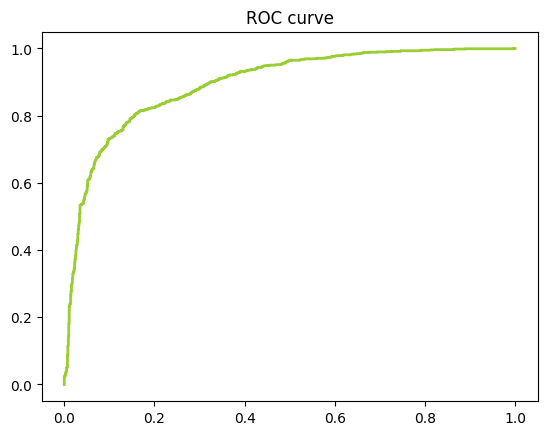

In [ ]:
plt.plot(fpr, tpr, c='yellowgreen', linewidth=2)
plt.title('ROC curve')
plt.show()

In [ ]:
res = roc_auc_score(y_test, pred[:, 1])
f"Площадь под ROC кривой составляет {round(res,3)}"

'Площадь под ROC кривой составляет 0.895'

In [ ]:
tp, fp, fn, tn = 0, 0, 0, 0

for truth, pr in zip(y_test, pred[:, 1]):
  if pr >= 0.5:
    if truth == 1:
      tp += 1
    else:
      fp += 1
  if pr < 0.5:
    if truth == 0:
      tn += 1
    else:
      fn += 1

print(tp, fp, fn, tn )


963 201 205 803


In [ ]:
TPR = tp / (tp + fn)
FPR = fp / (fp + tn)

In [ ]:
TPR, FPR

(0.824486301369863, 0.20019920318725098)

In [ ]:
pre, rec = [], []
TPRs, FPRs = [], []
for i in np.linspace(0.01, 0.99, 30):
  tp, fp, fn, tn = 0, 0, 0, 0
  for truth, pr in zip(y_test, pred[:, 1]):
    if pr >= i:
      if truth == 1:
        tp += 1
      else:
        fp += 1
    if pr < i:
      if truth == 0:
        tn += 1
      else:
        fn += 1
  tprs = tp / (tp + fn)
  TPRs.append(tprs)
  fprs = fp / (fp + tn)
  FPRs.append(fprs)
  pres = tp / (tp + fp)
  pre.append(pres)
  recs = tp / (tp + fn)
  rec.append(recs)


In [ ]:
pre, rec

([0.5400277649236465,
  0.5626808100289296,
  0.5886524822695035,
  0.6167377398720683,
  0.6456338028169014,
  0.6666666666666666,
  0.6929716399506781,
  0.7150259067357513,
  0.7283044058744993,
  0.7454923717059639,
  0.7586455331412104,
  0.772795216741405,
  0.7879499217527387,
  0.8008097165991903,
  0.818105616093881,
  0.8454706927175843,
  0.8627450980392157,
  0.8740079365079365,
  0.8899273104880582,
  0.9016393442622951,
  0.9112903225806451,
  0.9204406364749081,
  0.9305373525557011,
  0.9314685314685315,
  0.9458204334365325,
  0.9448398576512456,
  0.9466950959488273,
  0.9539295392953929,
  0.9549180327868853,
  0.9090909090909091],
 [0.9991438356164384,
  0.9991438356164384,
  0.9948630136986302,
  0.990582191780822,
  0.9811643835616438,
  0.9708904109589042,
  0.9623287671232876,
  0.9452054794520548,
  0.9340753424657534,
  0.9203767123287672,
  0.901541095890411,
  0.8852739726027398,
  0.8621575342465754,
  0.8467465753424658,
  0.8356164383561644,
  0.815068493

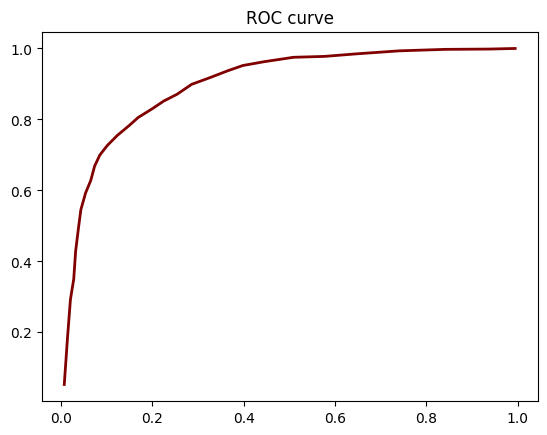

In [ ]:
plt.plot(FPRs, TPRs, c='maroon', linewidth=2)
plt.title('ROC curve')
plt.show()

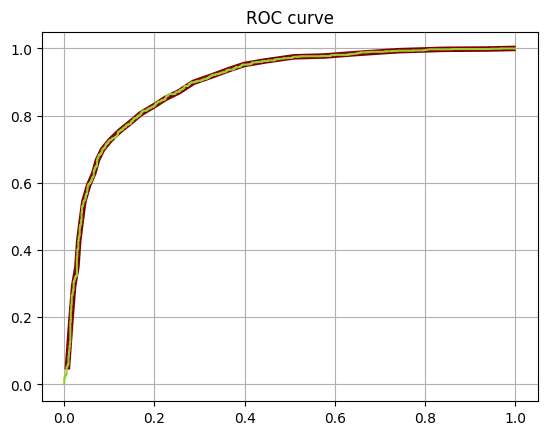

In [ ]:
plt.plot(FPRs, TPRs, c='maroon', linewidth=4)
plt.plot(fpr, tpr, c='yellowgreen')
plt.title('ROC curve')
plt.grid()
plt.show()

In [ ]:
auc(FPRs, TPRs)

0.8929336923964717

In [ ]:
pr, re, _ = precision_recall_curve(y_test, pred[:, 1])

In [ ]:
average_precision_score(y_test, pred[:, 1])

0.8996955802186681

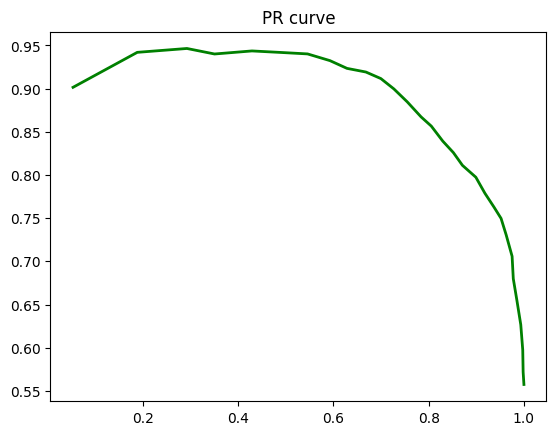

In [ ]:
plt.plot(rec, pre, c='g', linewidth=2)
plt.title('PR curve')
plt.show()

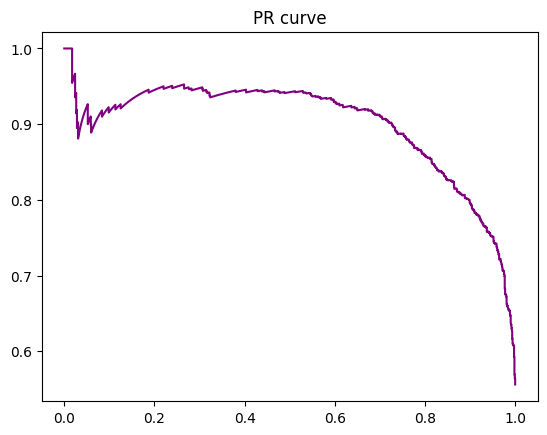

In [ ]:
plt.plot(re, pr, c='purple')
plt.title('PR curve')
plt.show()

☝ 2 вариант

In [ ]:
df = pd.read_csv('athletes.csv')
df.head(3)

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [ ]:
df['height'].isna().sum()

330

In [ ]:
df['weight'].isna().sum()

659

In [ ]:
df[df['height'].isna()].head(3)

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
12,258556239,Abbas Qali,IOA,male,10/11/92,NaN,NaN,aquatics,0,0,0
47,469953606,Abdoullah Bamoussa,ITA,male,6/8/86,NaN,NaN,athletics,0,0,0
50,325809293,Abdul Omar,GHA,male,10/3/93,NaN,NaN,boxing,0,0,0


In [ ]:
df = df[~(df['height'].isna())]
df = df[~(df['weight'].isna())]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10858 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10858 non-null  int64  
 1   name         10858 non-null  object 
 2   nationality  10858 non-null  object 
 3   sex          10858 non-null  object 
 4   dob          10858 non-null  object 
 5   height       10858 non-null  float64
 6   weight       10858 non-null  float64
 7   sport        10858 non-null  object 
 8   gold         10858 non-null  int64  
 9   silver       10858 non-null  int64  
 10  bronze       10858 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 1017.9+ KB


In [ ]:
df['sex'].value_counts()

,count
sex,
male,5862
female,4996


In [ ]:
x = pd.get_dummies(df.loc[:, ['height', 'weight', 'sport']])
x.head(3)

,height,weight,sport_aquatics,sport_archery,sport_athletics,sport_badminton,sport_basketball,sport_canoe,sport_cycling,sport_equestrian,...,sport_rugby sevens,sport_sailing,sport_shooting,sport_table tennis,sport_taekwondo,sport_tennis,sport_triathlon,sport_volleyball,sport_weightlifting,sport_wrestling
0,1.72,64.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.68,56.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.98,79.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
lab = LabelEncoder()
lab.fit(df['sex'])
y = pd.Series(data=lab.transform(df['sex']))
y.head()

,0
0,1
1,0
2,1
3,1
4,1


In [ ]:
data = LogisticRegression(max_iter=1000)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [ ]:
data.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
data.predict(x_test)

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
pred = data.predict_proba(x_test)
pred

array([[0.10984318, 0.89015682],
       [0.14668693, 0.85331307],
       [0.42766506, 0.57233494],
       ...,
       [0.91498873, 0.08501127],
       [0.83883877, 0.16116123],
       [0.92703439, 0.07296561]])

In [ ]:
fpr, tpr, threshold = roc_curve(y_test, pred[:, 1])

for line in zip(fpr[:5], tpr[:5], threshold[:5]):
  print(line)

(0.0, 0.0, inf)
(0.0, 0.0008278145695364238, 0.9999838579082738)
(0.0, 0.0173841059602649, 0.9989427665569226)
(0.001037344398340249, 0.0173841059602649, 0.9988580605779662)
(0.001037344398340249, 0.01903973509933775, 0.9987776081113741)


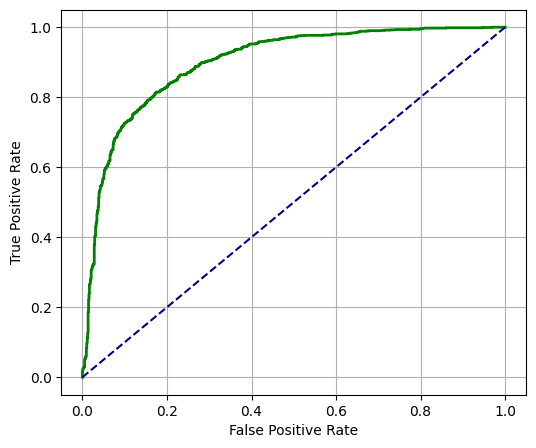

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'green', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()

In [ ]:
roc_auc_score(y_test, pred[:, 1])

0.8984377146822016

In [ ]:
auc(fpr, tpr)

0.8984377146822016

In [ ]:
TN, FP, FN, TP = 0, 0, 0, 0

for predicted_prob, actual in zip( pred[:, 1], y_test):
  if predicted_prob >= 0.5:
       predicted = 1
  else:
       predicted = 0
  if predicted == 1:
        if actual == 1:
            TP += 1
        else:
            FP += 1
  else:
        if actual == 1:
            FN += 1
        else:
            TN += 1

In [ ]:
TN, FP, FN, TP

(789, 175, 223, 985)

In [ ]:
(TP + TN) / (TP + FP + FN + TN)

0.8167587476979742

In [ ]:
TPR = TP / (TP + FN)
FPR =  FP / (FP + TN)

print(f'TPR: {TPR: 0.3f}')
print(f'FPR: {FPR: 0.3f}')

TPR:  0.815
FPR:  0.182


In [ ]:
pred[:, 1]

array([0.89015682, 0.85331307, 0.57233494, ..., 0.08501127, 0.16116123,
       0.07296561])

In [ ]:
y_test

,0
6267,1
4413,1
10147,0
1623,0
3802,0
...,...
7329,1
9564,0
1120,0
4705,0


In [ ]:
tpr_list = []
fpr_list = []

In [ ]:
for thresh in np.linspace(0, 1, 100):
    TN, FP, FN, TP = 0, 0, 0, 0
    for predicted_prob, actual in zip( pred[:, 1], y_test):
        if predicted_prob >= thresh:
            predicted = 1
        else:
            predicted = 0
        if predicted == 1:
            if actual == 1:
                TP += 1
            else:
                FP += 1
        else:
            if actual == 1:
                FN += 1
            else:
                TN += 1

    try:
        tpr_list.append(TP / (TP + FN))
    except ZeroDivisionError:
        tpr_list.append(0)

    try:
        fpr_list.append(FP / (FP + TN))
    except ZeroDivisionError:
        fpr_list.append(0)

len(tpr_list), len(fpr_list)

(100, 100)

In [ ]:
tpr_list[:7]

[1.0,
 1.0,
 1.0,
 0.9991721854304636,
 0.9983443708609272,
 0.9983443708609272,
 0.9983443708609272]

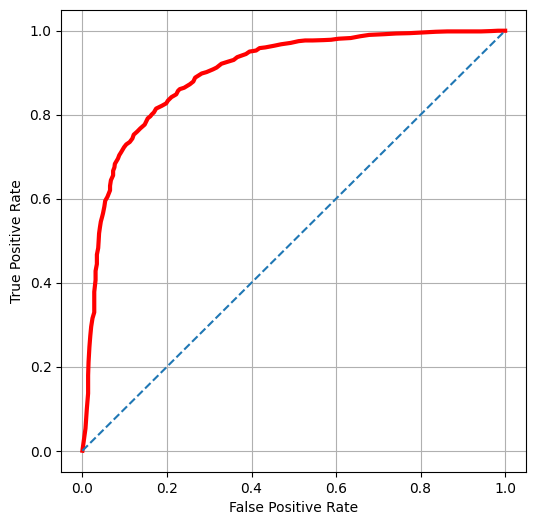

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, 'red', lw=3)
plt.plot([0, 1], [0, 1], linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()

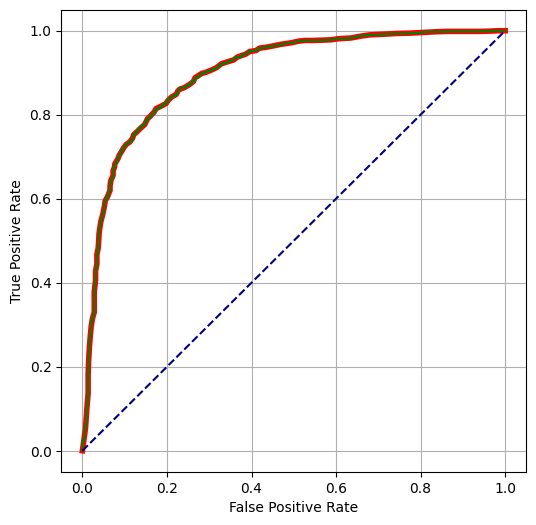

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_list, tpr_list, 'red', lw=4)
plt.plot(fpr, tpr, 'green')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()

In [ ]:
TN, FP, FN, TP = 0, 0, 0, 0

for predicted_prob, actual in zip( pred[:, 1], y_test):
  if predicted_prob >= 0.5:
       predicted = 1
  else:
       predicted = 0
  if predicted == 1:
        if actual == 1:
            TP += 1
        else:
            FP += 1
  else:
        if actual == 1:
            FN += 1
        else:
            TN += 1

In [ ]:
recall = TP / (TP + FN)
precision = TP / (TP + FP)

print(f'Recall: {recall: 0.3f}')
print(f'Precision: {precision: 0.3f}')

Recall:  0.815
Precision:  0.849


In [ ]:
pre, rec, thres = precision_recall_curve(y_test, pred[:, 1])

pre.shape, rec.shape

((1941,), (1941,))

In [ ]:
for lines in zip(pre[:5], rec[:5], thres[:5]):
  print(lines)

(0.5331775700934579, 1.0, 0.027770090226309364)
(0.5329593267882188, 0.9991235758106923, 0.0280631498398908)
(0.5332086061739943, 0.9991235758106923, 0.028476444783648518)
(0.5334581188582125, 0.9991235758106923, 0.028518137049557354)
(0.5337078651685393, 0.9991235758106923, 0.02962924646940829)


(0.0, 1.0)

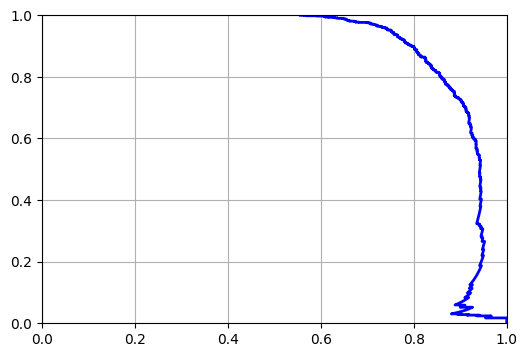

In [ ]:
plt.figure(figsize = (6, 4))
plt.plot(pre, rec, color = 'blue', lw=2)
plt.grid()
plt.xlim(0, 1)
plt.ylim(0, 1)

In [ ]:
average_precision_score(y_test, pred[:, 1])

0.8996955802186681

In [ ]:
pre_list = []
rec_list = []

In [ ]:
for thresh in np.linspace(0.01, 0.99, 100):
  for predicted_prob, actual in zip( pred[:, 1], y_test):
    TN, FP, FN, TP = 0, 0, 0, 0
    if predicted_prob >= thresh:
       predicted = 1
    else:
       predicted = 0
    if predicted == 1:
        if actual == 1:
            TP += 1
        else:
            FP += 1
    else:
        if actual == 1:
            FN += 1
        else:
            TN += 1
  try:
    pre_list.append(TP / (TP + FP))
  except ZeroDivisionError:
    pre_list.append(0)

  try:
    rec_list.append(TP / (TP + FN))
  except ZeroDivisionError:
    rec_list.append(0)

len(rec_list), len(pre_list)

(300, 300)

In [ ]:
print(rec_list)
print(pre_list)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

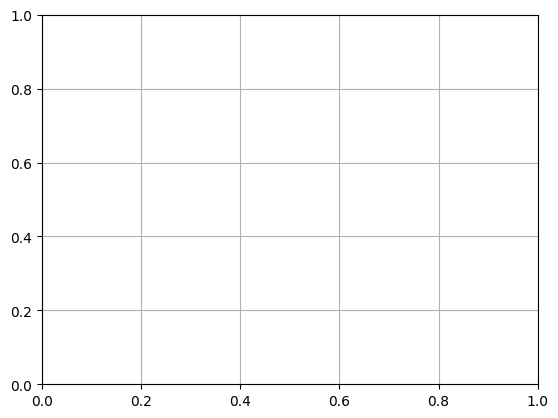

In [ ]:
plt.plot(pre_list, rec_list, color = 'red', lw=3)
plt.grid()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

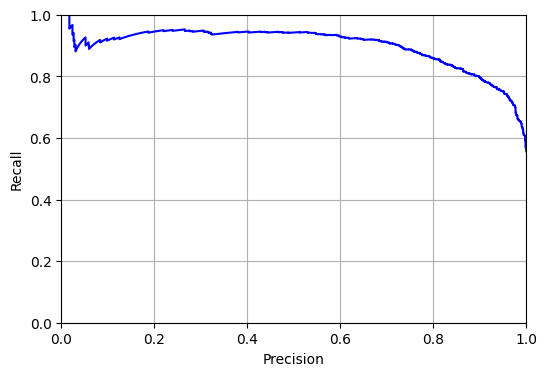

In [ ]:
plt.figure(figsize = (6, 4))
plt.plot(rec, pre, color = 'blue')
plt.plot(pre_list, rec_list, color = 'red', lw=3)
plt.grid()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.show()